# Irreducible Mass of Black Holes

$f(\chi) = M_{irr} = M \sqrt{\frac{1+\sqrt{1-\chi^{2}}}{2}}$ with the spin $\chi \in [0,1]$ is the irreducible mass of a black hole.

Suppouse you have repeated measurements of $M$ and $\chi$ and let's assume that
 - the spin is uniformly distributed between $0$ and $1$.
 - the mass $M$ is normally distributed with mean $\mu$ and standard distribution $\sigma$.
 - (masses and spins are uncorrelated)

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import sys
sys.path.append(r"C:\Users\ricca\Documents\Unimib-Code\Astrostatistics\Notebooks")
from Utilities import plot_settings
from scipy import stats
import scipy

In [2]:
N = int(1e4)

In [3]:
chi = np.random.uniform(0,1,N)[:-1] # Chi values extracted from uniform distribution
mu = 1 # for convenience
sigma = 0.02
M   = np.random.normal(mu,sigma,N) # M values extracted from normal distribution

In [4]:
def f(chi):
    return np.sqrt(0.5 * (1+np.sqrt(1-chi**2)))

def Mirr(M,chi):
    try:
        M.size == chi.size
    except:
        raise IndexError("Sizes of masses and spins should be equal!")
    return M*f(chi)

9. **Using the expressions from point 7 and 8, plot those pdfs check that they agree with your KDE reconstructions.**

NameError: name 'f_pdf' is not defined

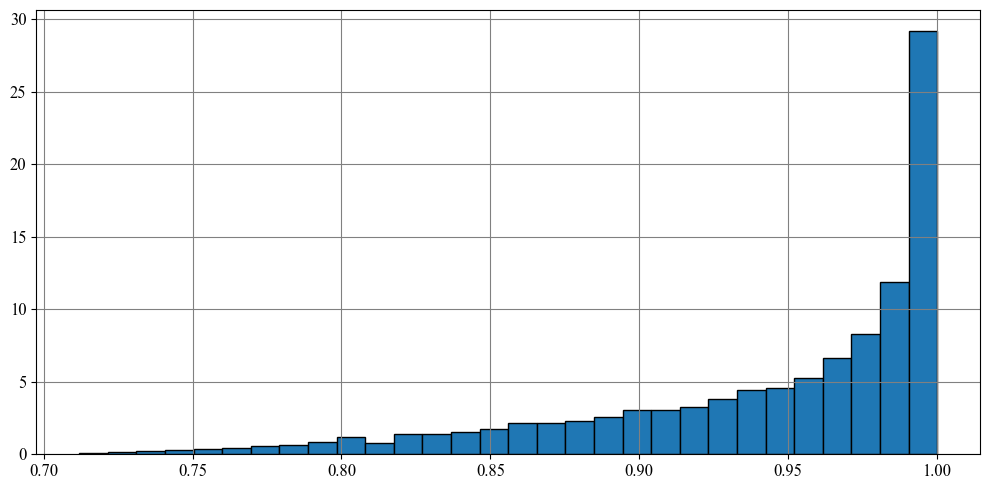

In [5]:
x_plot = np.linspace(1/2**0.5,1,N)[:-1]
t,_,_=plt.hist(f(chi), bins='scott',density=True, histtype='barstacked', edgecolor='black')
plt.plot(x_plot, f_pdf(x_plot))
plt.title(r'$f(\chi)$ distribution')
plt.xlabel(r'$f(\chi)$')
plt.ylabel(r'counts')
plt.ylim(0,max(t))

(0.0, 20.21712937630064)

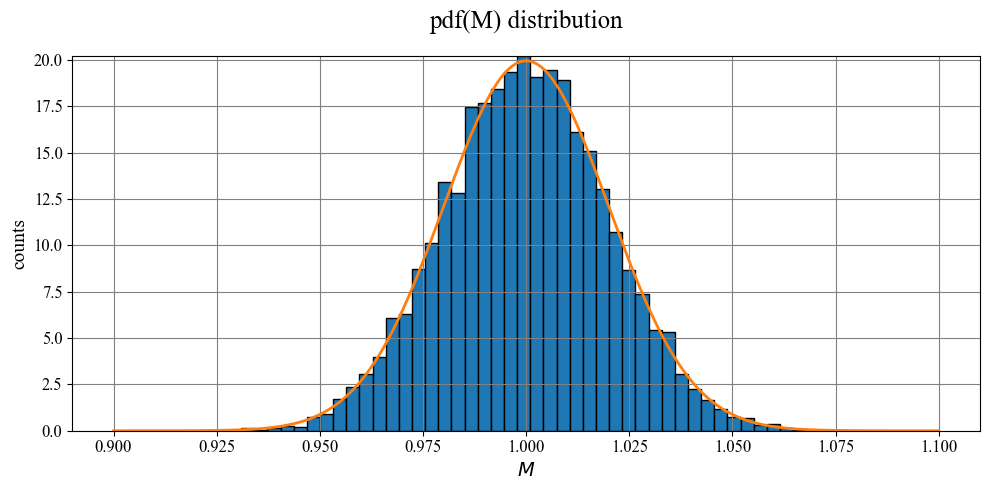

In [ ]:
x_plot = np.linspace(1-5*sigma,1+5*sigma,N)
t,_,_=plt.hist(M, bins='scott',density=True, histtype='barstacked', edgecolor='black')
m = scipy.stats.norm.pdf(x_plot,mu,sigma)
plt.plot(x_plot, m)
plt.title(r'pdf(M) distribution')
plt.xlabel(r'$M$')
plt.ylabel(r'counts')
plt.ylim(0,max(t))

1. **Start with a value of $\sigma = 0.02$. Note that $\mu$ is a scale and not a parameter: you can normalize all quantities with a  dimenion of mass by $\mu$. Just set $\mu = 1$ and remember that all masses are measured in units of $\mu$.**

In [75]:
chi = np.random.uniform(0,1,N) # Chi values extracted from uniform distribution
mu = 1 # for convenience
sigma = 0.02
M   = np.random.normal(mu,sigma,N) # M values extracted from normal distribution
data = Mirr(M,chi)

2. **Plot the resulting pdf of $M_{irr}$. First try an histogram with one of the rules of thumb seen during lecture**

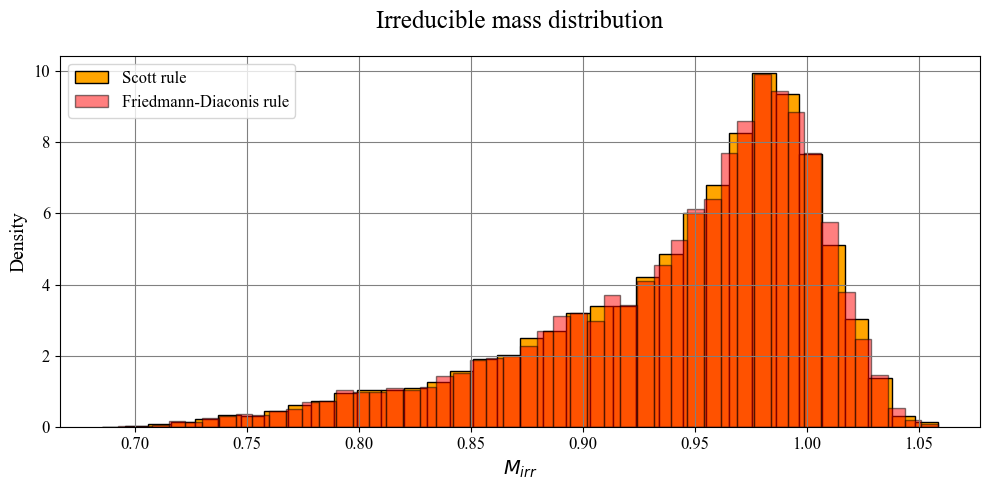

In [7]:
scott_c, scott_b, _ = plt.hist(data, density=True, bins='scott', histtype='barstacked', color='orange', edgecolor='black', label='Scott rule')
fd_c, fd_b, _ = plt.hist(data, bins='fd', density=True, histtype='barstacked', color='red', edgecolor='black', alpha=0.5, label='Friedmann-Diaconis rule')
plt.title('Irreducible mass distribution')
plt.ylabel('Density')
plt.xlabel(r'$M_{irr}$')
plt.legend()

3. **Using the same samples as in the previous point, plot the distribution of $M_{irr}$ using KDE**

In [ ]:
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import train_test_split, GridSearchCV, KFold

In [76]:
train, test = train_test_split(data, test_size=0.3, shuffle=True, random_state=42)

Perform Cross-Validation to know which kernel and bandwidth combination is the best one to use

In [86]:
custom_cv = KFold(n_splits=10, shuffle=True, random_state=42)

params = {
    'bandwidth'  : list(np.linspace(0.01, 1.0, 10)),
    'kernel'     : ['gaussian', 'kernel', 'tophat']
}

# GridSearchCV
grid = GridSearchCV(KernelDensity(),
                    param_grid=params,
                    cv=custom_cv,
                    verbose=3)
grid.fit(data.reshape(-1,1))

Fitting 10 folds for each of 30 candidates, totalling 300 fits
[CV 1/10] END bandwidth=0.01, kernel=gaussian;, score=1530.058 total time=   1.4s
[CV 2/10] END bandwidth=0.01, kernel=gaussian;, score=1496.123 total time=   1.2s
[CV 3/10] END bandwidth=0.01, kernel=gaussian;, score=1499.687 total time=   0.6s
[CV 4/10] END bandwidth=0.01, kernel=gaussian;, score=1563.864 total time=   0.5s
[CV 5/10] END bandwidth=0.01, kernel=gaussian;, score=1522.383 total time=   0.5s
[CV 6/10] END bandwidth=0.01, kernel=gaussian;, score=1465.908 total time=   0.5s
[CV 7/10] END bandwidth=0.01, kernel=gaussian;, score=1509.759 total time=   0.5s
[CV 8/10] END bandwidth=0.01, kernel=gaussian;, score=1512.291 total time=   0.5s
[CV 9/10] END bandwidth=0.01, kernel=gaussian;, score=1529.146 total time=   0.5s
[CV 10/10] END bandwidth=0.01, kernel=gaussian;, score=1501.543 total time=   0.5s
[CV 1/10] END ......bandwidth=0.01, kernel=kernel;, score=nan total time=   0.0s
[CV 2/10] END ......bandwidth=0.01,

c:\Users\ricca\Documents\Unimib-Code\Astrostatistics\Notebooks\venv\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
100 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ricca\Documents\Unimib-Code\Astrostatistics\Notebooks\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 864, in _fit_and_score
    estimator.fit(X_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ricca\Documents\Unimib-Code\Astrostatistics\Notebooks\venv\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~

GridSearchCV(cv=KFold(n_splits=10, random_state=42, shuffle=True),
             estimator=KernelDensity(),
             param_grid={'bandwidth': [np.float64(0.01), np.float64(0.12),
                                       np.float64(0.23), np.float64(0.34),
                                       np.float64(0.45), np.float64(0.56),
                                       np.float64(0.67), np.float64(0.78),
                                       np.float64(0.89), np.float64(1.0)],
                         'kernel': ['gaussian', 'kernel', 'tophat']},
             verbose=3)

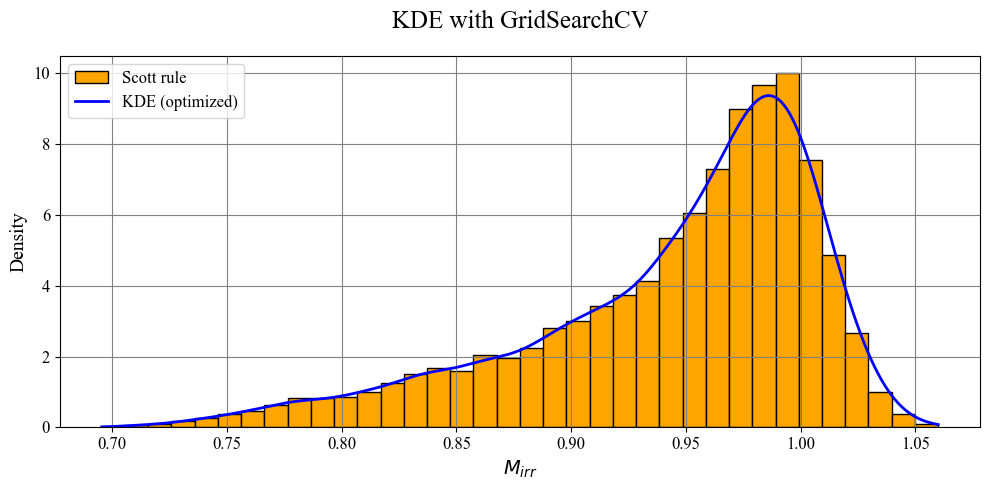

In [91]:
# Use best model
kde = grid.best_estimator_

# KDE evaluation
x_plot = np.linspace(data.min(), data.max(), 1000).reshape(-1, 1)
log_dens = kde.score_samples(x_plot)

# Plot
plt.hist(data.ravel(), bins='scott', density=True, color='orange', edgecolor='black', label='Scott rule')
plt.plot(x_plot.ravel(), np.exp(log_dens), color='blue', label='KDE (optimized)')
plt.title('KDE with GridSearchCV')
plt.xlabel(r'$M_{irr}$')
plt.ylabel('Density')
plt.legend()

4. **Compute the KS distance between $\frac{M_{irr}}{\mu}$ and $f(\chi)$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$.**
5. **Compute the KS distance between $M_{irr}$ and $M$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$.**

In [215]:
sigmas = np.power(10, np.linspace(-3, 1, 50))

In [216]:
def compute_cdf(x, plot=False):

   x      = np.sort(np.array(x))  
   ecdf_y = np.arange(1, len(data) + 1) / len(data)

   if plot:
      plt.plot(ecdf_y, marker='.', linestyle='none')
      plt.xlabel(r'$M_{irr}$')
      plt.ylabel('ECDF')
      plt.title('Empirical CDF')
      plt.grid(True)
      plt.show()

   return ecdf_y

In [217]:
from scipy.stats import ks_2samp

In [231]:
Dchi, DM_ = [], []
for s in sigmas:
    M_ = np.random.normal(mu,s,N)
    D = Mirr(M_,chi)
    Dchi.append(ks_2samp(D, f(chi), method='exact'))
    DM_.append(ks_2samp(D, M_, method='exact'))

In [232]:
Dchi = np.array(Dchi)
DM_  = np.array(DM_)

Text(0.5, 0.98, 'Kolmogorov-Smirnoff Test')

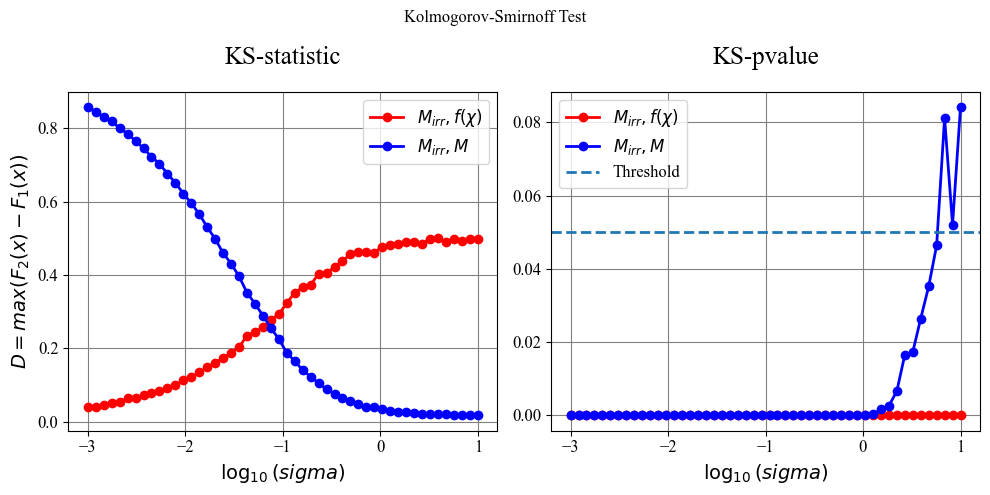

In [234]:
fig, axs = plt.subplots(1, 2)
axs[0].plot(np.log10(sigmas), Dchi.T[0], marker='o', color='red', lw=2, label=r'$M_{irr}, f(\chi)$')
axs[0].plot(np.log10(sigmas), DM_.T[0], marker='o', color='blue', lw=2, label=r'$M_{irr}, M$')
axs[0].set_xlabel(r'$\log_{10}(sigma)$')
axs[0].set_ylabel(r'$D = max(F_2(x) - F_1(x))$')
axs[0].set_title('KS-statistic')
axs[0].legend()

axs[1].plot(np.log10(sigmas), Dchi.T[1], marker='o', color='red', lw=2, label=r'$M_{irr}, f(\chi)$')
axs[1].plot(np.log10(sigmas), DM_.T[1], marker='o', color='blue', lw=2, label=r'$M_{irr}, M$')
axs[1].axhline(0.05,0, 1, linestyle='--', lw=2, label='Threshold')
axs[1].set_xlabel(r'$\log_{10}(sigma)$')
axs[1].set_title('KS-pvalue')
axs[1].legend()
plt.suptitle('Kolmogorov-Smirnoff Test')

Seems like for very small sigma values the distribution of the irreducible mass tends to be more similar to that of $M$; as $\sigma \approx 1$ the distribution of the irreducible mass values tends rapidly to the distribution of $M$, which is a normal distribution $\mathcal{N}(\mu, \sigma)$.\
Looking at the p-value we can safely say that for $KS(M_{irr}, M)$:
 - Untill $\sigma \approx \sqrt{10}$ p-value $< 0.05$ thus I can reject the null hypothesis and conclude that the samples are drawn from significantly different distribution $\to$ $M_{irr}$ distribution is very different from a normal.
 - As $\sigma$ surpasses that point, I do not posses enough evidence to say that I can reject the null hypothesis (distribution of $M_{irr}$ is very similar to a gaussian)

 I'd like to confirm this also visually.

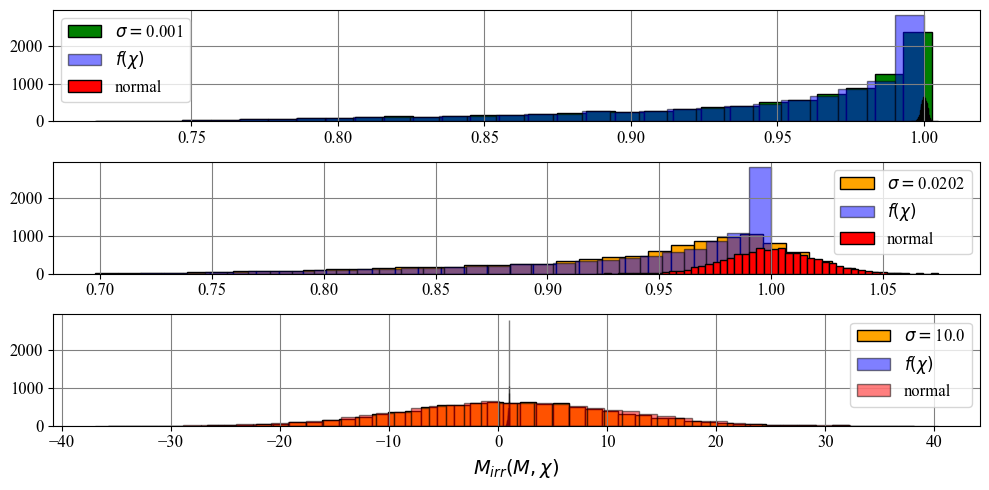

In [247]:
fig, axs = plt.subplots(3, 1)

axs[0].hist(Mirr(np.random.normal(mu,sigmas[0],N),chi), bins='scott', histtype='barstacked', color='green', 
            edgecolor='black', label=r'$\sigma = $'+f'{sigmas[0]:.3}');
axs[0].hist(f(chi), bins='scott', histtype='barstacked', color='blue',
            edgecolor='black', label=r'$f(\chi)$', alpha=0.5);
axs[0].hist(np.random.normal(mu,sigmas[0],N), bins='scott', histtype='barstacked', color='red', 
            edgecolor='black', label=r'normal', alpha=1);

axs[1].hist(Mirr(np.random.normal(mu,sigmas[int(len(sigmas)/3)],N),chi), bins='scott', histtype='barstacked', color='orange', 
            edgecolor='black', label=r'$\sigma = $'+f'{sigmas[int(len(sigmas)/3)]:.3}');
axs[1].hist(f(chi), bins='scott', histtype='barstacked', color='blue',
            edgecolor='black', label=r'$f(\chi)$', alpha=0.5);
axs[1].hist(np.random.normal(mu,sigmas[int(len(sigmas)/3)],N), bins='scott', histtype='barstacked', color='red', 
            edgecolor='black', label=r'normal', alpha=1);


axs[2].hist(Mirr(np.random.normal(mu,sigmas[-1],N),chi), bins='scott', histtype='barstacked', color='orange', 
            edgecolor='black', label=r'$\sigma = $'+f'{sigmas[-1]:.3}');
axs[2].hist(f(chi), bins='scott', histtype='barstacked', color='blue',
            edgecolor='black', label=r'$f(\chi)$', alpha=0.5);
axs[2].hist(np.random.normal(mu,sigmas[-1],N), bins='scott', histtype='barstacked', color='red', 
            edgecolor='black', label=r'normal', alpha=0.5);


axs[2].set_xlabel(r'$M_{irr}(M,\chi)$');
axs[0].legend();
axs[1].legend();
axs[2].legend();